In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,809c1_00000,0,0.650451,least_confidence,1,225.099059
1,1,809c1_00000,1,0.692617,least_confidence,1,225.099059
2,2,809c1_00000,2,0.737961,least_confidence,1,225.099059
3,3,809c1_00000,3,0.744679,least_confidence,1,225.099059
4,4,809c1_00000,4,0.827662,least_confidence,1,225.099059
...,...,...,...,...,...,...,...
4513,4513,809c1_00024,246,0.941752,random,5,225.767178
4514,4514,809c1_00024,247,0.932863,random,5,225.767178
4515,4515,809c1_00024,248,0.937893,random,5,225.767178
4516,4516,809c1_00024,249,0.924155,random,5,225.767178


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
3514,3514,809c1_00021,0,0.855750,random,2,206.989670
3515,3515,809c1_00021,1,0.427839,random,2,206.989670
3516,3516,809c1_00021,2,0.427604,random,2,206.989670
3517,3517,809c1_00021,3,0.444716,random,2,206.989670
3518,3518,809c1_00021,4,0.855750,random,2,206.989670
...,...,...,...,...,...,...,...
4513,4513,809c1_00024,246,0.941752,random,5,225.767178
4514,4514,809c1_00024,247,0.932863,random,5,225.767178
4515,4515,809c1_00024,248,0.937893,random,5,225.767178
4516,4516,809c1_00024,249,0.924155,random,5,225.767178


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_18688/2952143151.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])


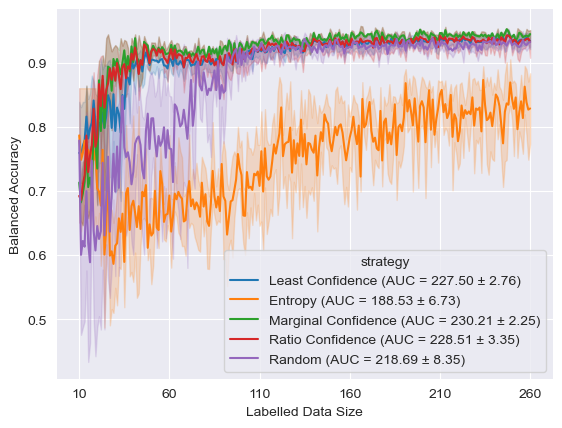

In [5]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Balanced Accuracy")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 10 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)